# Assignment 3: GPT Architecture Implementation

**Based on:** Chapter 4 - Implementing a GPT Model from Scratch  
**Objective:** Build a complete GPT-style model architecture from scratch, understanding each component's role in the transformer architecture.

In this assignment, we will implement:
1. Layer Normalization (LayerNorm)
2. GELU Activation Function
3. Feed-Forward Network (FFN)
4. Transformer Blocks (combining attention + FFN with residual connections)
5. Complete GPT Model with embeddings and positional encodings
6. Text generation without training (to verify model structure)

The model will consist of:
- Token embeddings to convert tokens to dense vectors
- Absolute positional embeddings to encode position information
- Multiple TransformerBlocks with multi-head attention and FFN
- Final layer normalization and output projection to vocabulary size

## Section 1: Import Required Libraries and Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
from typing import Tuple, Optional
import matplotlib.pyplot as plt
from dataclasses import dataclass

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.5.1+cu121


## Section 2: Implement Layer Normalization from Scratch

Layer Normalization (LayerNorm) normalizes activation values across features for each sample in a batch.

The formula is:
$$y = \gamma \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

Where:
- $\mu$ is the mean of the features
- $\sigma^2$ is the variance of the features
- $\gamma$ and $\beta$ are learnable parameters (scale and shift)
- $\epsilon$ is a small constant for numerical stability (usually 1e-5)

In [2]:
class LayerNorm(nn.Module):
    """
    Layer Normalization implementation from scratch.
    
    Normalizes inputs across the feature dimension (last dimension).
    """
    def __init__(self, emb_dim: int, eps: float = 1e-5):
        """
        Args:
            emb_dim: Embedding/feature dimension
            eps: Small constant for numerical stability
        """
        super().__init__()
        self.eps = eps
        # Learnable parameters
        self.scale = nn.Parameter(torch.ones(emb_dim))  # gamma
        self.shift = nn.Parameter(torch.zeros(emb_dim))  # beta
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Input tensor of shape (..., emb_dim)
            
        Returns:
            Normalized tensor of same shape
        """
        # Calculate mean and variance along the last dimension
        mean = x.mean(dim=-1, keepdim=True)
        variance = x.var(dim=-1, keepdim=True, unbiased=False)
        
        # Normalize
        x_norm = (x - mean) / torch.sqrt(variance + self.eps)
        
        # Apply learned scale and shift
        return self.scale * x_norm + self.shift


# Test LayerNorm implementation
print("Testing LayerNorm implementation:")
batch_size, seq_len, emb_dim = 2, 4, 8
x_test = torch.randn(batch_size, seq_len, emb_dim)

ln_custom = LayerNorm(emb_dim)
ln_pytorch = nn.LayerNorm(emb_dim)

# Copy weights for comparison
ln_pytorch.weight.data = ln_custom.scale.data.clone()
ln_pytorch.bias.data = ln_custom.shift.data.clone()

output_custom = ln_custom(x_test)
output_pytorch = ln_pytorch(x_test)

print(f"Input shape: {x_test.shape}")
print(f"Output shape: {output_custom.shape}")
print(f"Max difference between custom and PyTorch LayerNorm: {(output_custom - output_pytorch).abs().max().item():.2e}")
print(f"Outputs match: {torch.allclose(output_custom, output_pytorch, atol=1e-6)}\n")

Testing LayerNorm implementation:
Input shape: torch.Size([2, 4, 8])
Output shape: torch.Size([2, 4, 8])
Max difference between custom and PyTorch LayerNorm: 2.38e-07
Outputs match: True



## Section 3: Implement GELU Activation Function

GELU (Gaussian Error Linear Unit) is an activation function that uses cumulative distribution function (CDF) of the standard normal distribution:

$$\text{GELU}(x) = x \cdot \Phi(x)$$

Where $\Phi(x)$ is the CDF of the standard normal distribution. We'll use the approximation:

$$\text{GELU}(x) \approx 0.5x \left(1 + \tanh\left(\sqrt{\frac{2}{\pi}}(x + 0.044715x^3)\right)\right)$$

GELU tends to produce smoother gradients compared to ReLU, making it excellent for transformer models.

Testing GELU activation function:
Input range: [-3.00, 3.00]
Max difference between custom and PyTorch GELU: 0.00e+00
Outputs match: True


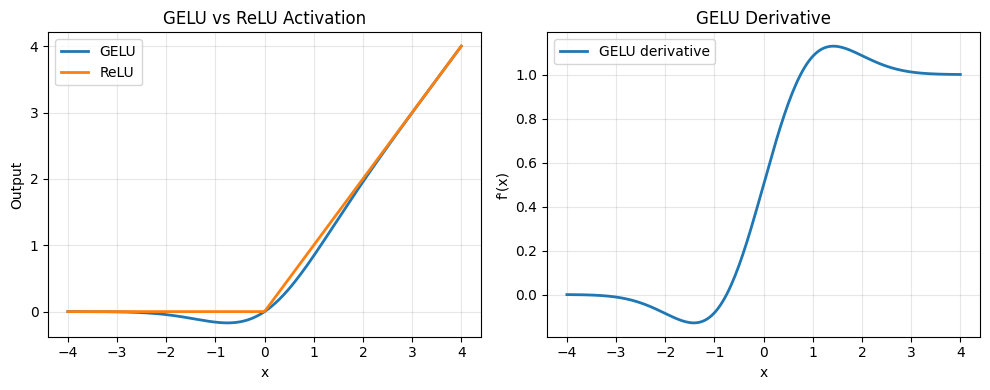

In [3]:
class GELU(nn.Module):
    """
    GELU activation function implementation from scratch.
    Uses the approximation: GELU(x) ≈ 0.5x(1 + tanh(sqrt(2/π)(x + 0.044715x³)))
    """
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Input tensor of any shape
            
        Returns:
            Activated tensor of same shape
        """
        cdf = 0.5 * (1.0 + torch.tanh(
            math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3))
        ))
        return x * cdf


# Test GELU implementation and compare with PyTorch
print("Testing GELU activation function:")
x_test = torch.linspace(-3, 3, 100)

gelu_custom = GELU()
gelu_pytorch = nn.GELU(approximate='tanh')  # Use same approximation

output_custom = gelu_custom(x_test)
output_pytorch = gelu_pytorch(x_test)

print(f"Input range: [{x_test.min():.2f}, {x_test.max():.2f}]")
print(f"Max difference between custom and PyTorch GELU: {(output_custom - output_pytorch).abs().max().item():.2e}")
print(f"Outputs match: {torch.allclose(output_custom, output_pytorch, atol=1e-6)}")

# Visualize GELU vs ReLU
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
x_viz = torch.linspace(-4, 4, 200)
plt.plot(x_viz.numpy(), GELU()(x_viz).detach().numpy(), label='GELU', linewidth=2)
plt.plot(x_viz.numpy(), F.relu(x_viz).numpy(), label='ReLU', linewidth=2)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('Output')
plt.legend()
plt.title('GELU vs ReLU Activation')

# Plot derivatives
plt.subplot(1, 2, 2)
x_deriv = torch.linspace(-4, 4, 200, requires_grad=True)
gelu_out = GELU()(x_deriv).sum()
gelu_deriv = torch.autograd.grad(gelu_out, x_deriv, create_graph=True)[0].detach()
plt.plot(x_deriv.detach().numpy(), gelu_deriv.numpy(), label='GELU derivative', linewidth=2)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title('GELU Derivative')
plt.legend()
plt.tight_layout()
plt.show()
print()

## Section 4: Implement Feed-Forward Network

The Feed-Forward Network (FFN) in transformers is a two-layer MLP applied to each position separately:

1. **First layer** (Expansion): Linear transformation from $d_{model}$ to $4 \cdot d_{model}$
2. **Activation**: Apply GELU to introduce non-linearity
3. **Second layer** (Projection): Linear transformation back from $4 \cdot d_{model}$ to $d_{model}$
4. **Dropout**: Optional regularization

The expansion factor of 4 is commonly used in transformer models and helps the model learn more complex transformations.

In [4]:
class FeedForward(nn.Module):
    """
    Feed-Forward Network (FFN) module.
    Two-layer MLP with expansion factor of 4.
    """
    def __init__(self, d_model: int, d_ff: int = None, dropout: float = 0.1):
        """
        Args:
            d_model: Model dimension (input and output dimension)
            d_ff: Intermediate dimension. If None, defaults to 4 * d_model
            dropout: Dropout probability
        """
        super().__init__()
        if d_ff is None:
            d_ff = 4 * d_model
            
        # Two-layer MLP
        self.fc1 = nn.Linear(d_model, d_ff)  # Expansion layer
        self.gelu = GELU()                    # Activation
        self.fc2 = nn.Linear(d_ff, d_model)  # Projection layer
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Input tensor of shape (batch_size, seq_len, d_model)
            
        Returns:
            Output tensor of same shape as input
        """
        x = self.fc1(x)           # (batch, seq_len, d_ff)
        x = self.gelu(x)           # Apply GELU activation
        x = self.dropout(x)        # Apply dropout
        x = self.fc2(x)            # (batch, seq_len, d_model)
        x = self.dropout(x)        # Apply dropout again
        return x


# Test FeedForward network
print("Testing FeedForward Network:")
batch_size, seq_len, d_model = 2, 4, 8
x_test = torch.randn(batch_size, seq_len, d_model)

ff_net = FeedForward(d_model)
output = ff_net(x_test)

print(f"Input shape: {x_test.shape}")
print(f"Output shape: {output.shape}")
print(f"Shapes match: {x_test.shape == output.shape}")

# Count parameters in FFN
total_params = sum(p.numel() for p in ff_net.parameters())
print(f"Total parameters in FFN: {total_params}")
print(f"Breakdown: fc1={ff_net.fc1.weight.numel() + ff_net.fc1.bias.numel()}, "
      f"fc2={ff_net.fc2.weight.numel() + ff_net.fc2.bias.numel()}\n")

Testing FeedForward Network:
Input shape: torch.Size([2, 4, 8])
Output shape: torch.Size([2, 4, 8])
Shapes match: True
Total parameters in FFN: 552
Breakdown: fc1=288, fc2=264



## Section 5: Implement Multi-Head Attention

Multi-head attention allows the model to attend to different representation subspaces at different positions:

In [5]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention mechanism from Assignment 2.
    Split embedding into multiple heads for parallel attention computation.
    """
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        """
        Args:
            d_model: Model dimension
            num_heads: Number of attention heads
            dropout: Dropout probability
        """
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.scale = 1.0 / math.sqrt(self.head_dim)
        
        # Linear layers for Q, K, V projections
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)  # Output projection
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        Args:
            x: Input tensor of shape (batch_size, seq_len, d_model)
            mask: Causal mask to prevent attending to future tokens
            
        Returns:
            Output tensor of shape (batch_size, seq_len, d_model)
        """
        batch_size, seq_len, _ = x.shape
        
        # Project to Q, K, V
        Q = self.W_q(x)  # (batch, seq_len, d_model)
        K = self.W_k(x)  # (batch, seq_len, d_model)
        V = self.W_v(x)  # (batch, seq_len, d_model)
        
        # Reshape for multi-head attention
        # (batch, seq_len, d_model) -> (batch, seq_len, num_heads, head_dim)
        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        # Now: (batch, num_heads, seq_len, head_dim)
        
        # Compute attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1))  # (batch, num_heads, seq_len, seq_len)
        scores = scores * self.scale  # Scale by sqrt(head_dim)
        
        # Apply causal mask (optional)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        # Apply softmax to get attention weights
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # Apply attention to values
        attn_output = torch.matmul(attn_weights, V)  # (batch, num_heads, seq_len, head_dim)
        
        # Concatenate heads
        attn_output = attn_output.transpose(1, 2).contiguous()  # (batch, seq_len, num_heads, head_dim)
        attn_output = attn_output.view(batch_size, seq_len, self.d_model)  # (batch, seq_len, d_model)
        
        # Final output projection
        output = self.W_o(attn_output)
        
        return output


# Test MultiHeadAttention
print("Testing MultiHeadAttention:")
batch_size, seq_len, d_model, num_heads = 2, 4, 8, 2
x_test = torch.randn(batch_size, seq_len, d_model)

mha = MultiHeadAttention(d_model, num_heads)
output = mha(x_test)

print(f"Input shape: {x_test.shape}")
print(f"Output shape: {output.shape}")
print(f"Number of attention heads: {num_heads}")
print(f"Dimension per head: {d_model // num_heads}")
print(f"Total parameters in MHA: {sum(p.numel() for p in mha.parameters())}\n")

Testing MultiHeadAttention:
Input shape: torch.Size([2, 4, 8])
Output shape: torch.Size([2, 4, 8])
Number of attention heads: 2
Dimension per head: 4
Total parameters in MHA: 288



## Section 6: Implement Transformer Block

A TransformerBlock combines Multi-Head Attention and Feed-Forward Network with residual connections and layer normalization.

In [6]:
class TransformerBlock(nn.Module):
    """
    Transformer Block: Multi-Head Attention + Feed-Forward Network
    with residual connections and layer normalization (pre-norm architecture).
    
    Architecture:
    1. LayerNorm
    2. MultiHeadAttention
    3. Residual connection
    4. LayerNorm
    5. FeedForward
    6. Residual connection
    """
    def __init__(self, d_model: int, num_heads: int, d_ff: int = None, dropout: float = 0.1):
        """
        Args:
            d_model: Model dimension
            num_heads: Number of attention heads
            d_ff: Feed-forward intermediate dimension
            dropout: Dropout probability
        """
        super().__init__()
        
        # Attention sub-layer
        self.ln1 = LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)
        
        # Feed-forward sub-layer
        self.ln2 = LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff, dropout)
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        Args:
            x: Input tensor of shape (batch_size, seq_len, d_model)
            mask: Optional causal mask for attention
            
        Returns:
            Output tensor of same shape as input
        """
        # Attention with residual and pre-norm
        attn_output = self.attn(self.ln1(x), mask)
        x = x + self.dropout(attn_output)
        
        # Feed-forward with residual and pre-norm
        ff_output = self.ff(self.ln2(x))
        x = x + self.dropout(ff_output)
        
        return x


# Test TransformerBlock
print("Testing TransformerBlock:")
batch_size, seq_len, d_model, num_heads = 2, 4, 8, 2
x_test = torch.randn(batch_size, seq_len, d_model)

tfm_block = TransformerBlock(d_model, num_heads)
output = tfm_block(x_test)

print(f"Input shape: {x_test.shape}")
print(f"Output shape: {output.shape}")
print(f"Shapes match: {x_test.shape == output.shape}")
print(f"Total parameters in TransformerBlock: {sum(p.numel() for p in tfm_block.parameters())}\n")

Testing TransformerBlock:
Input shape: torch.Size([2, 4, 8])
Output shape: torch.Size([2, 4, 8])
Shapes match: True
Total parameters in TransformerBlock: 872



## Section 7: Implement Complete GPT Model

Now we'll assemble all components into a complete GPT model with token embeddings, positional embeddings, and a stack of TransformerBlocks.

In [7]:
@dataclass
class GPTConfig:
    """Configuration for GPT model."""
    vocab_size: int = 50257  # GPT-2 vocabulary size
    context_length: int = 1024  # Maximum sequence length
    d_model: int = 768  # Embedding dimension
    num_layers: int = 12  # Number of transformer blocks
    num_heads: int = 12  # Number of attention heads
    d_ff: int = 3072  # Feed-forward hidden dimension (4 * d_model)
    dropout: float = 0.1
    
    def __post_init__(self):
        """Validate configuration."""
        assert self.d_model % self.num_heads == 0, \
            f"d_model ({self.d_model}) must be divisible by num_heads ({self.num_heads})"


class GPT(nn.Module):
    """
    GPT model implementation from scratch.
    
    Architecture:
    1. Token embedding: converts token IDs to embeddings
    2. Positional embedding: adds position information
    3. Stack of TransformerBlocks
    4. Layer normalization
    5. Linear projection to vocabulary size
    """
    def __init__(self, config: GPTConfig):
        """
        Args:
            config: GPT configuration
        """
        super().__init__()
        self.config = config
        
        # Token embeddings: (vocab_size, d_model)
        self.token_embedding = nn.Embedding(config.vocab_size, config.d_model)
        
        # Positional embeddings: (context_length, d_model)
        # Register as buffer (not trainable parameter, but part of model state)
        self.register_buffer(
            'positional_embedding',
            self._create_positional_embeddings(config.context_length, config.d_model)
        )
        
        # Dropout on combined embeddings
        self.embedding_dropout = nn.Dropout(config.dropout)
        
        # Stack of transformer blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(config.d_model, config.num_heads, config.d_ff, config.dropout)
            for _ in range(config.num_layers)
        ])
        
        # Final layer normalization
        self.final_ln = LayerNorm(config.d_model)
        
        # Linear projection to vocabulary size
        self.output_projection = nn.Linear(config.d_model, config.vocab_size)
        
        # Initialize weights
        self._init_weights()
        
    @staticmethod
    def _create_positional_embeddings(context_length: int, d_model: int) -> torch.Tensor:
        """
        Create positional embeddings using sinusoidal functions.
        
        Formula:
        PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
        PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
        """
        position = torch.arange(context_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float) * 
                             -(math.log(10000.0) / d_model))
        
        pe = torch.zeros(context_length, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:  # Handle odd dimensions
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        
        return pe.unsqueeze(0)  # Add batch dimension: (1, context_length, d_model)
    
    def _init_weights(self):
        """Initialize model weights."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    def forward(self, token_ids: torch.Tensor) -> torch.Tensor:
        """
        Args:
            token_ids: Input token indices of shape (batch_size, seq_len)
                      values should be in range [0, vocab_size)
            
        Returns:
            Logits of shape (batch_size, seq_len, vocab_size)
        """
        batch_size, seq_len = token_ids.shape
        
        # Ensure sequence is not longer than context length
        assert seq_len <= self.config.context_length, \
            f"Sequence length {seq_len} exceeds context length {self.config.context_length}"
        
        # Token embeddings
        token_emb = self.token_embedding(token_ids)  # (batch, seq_len, d_model)
        
        # Add positional embeddings
        pos_emb = self.positional_embedding[:, :seq_len, :]  # (1, seq_len, d_model)
        x = token_emb + pos_emb  # Broadcasting: (batch, seq_len, d_model)
        
        # Apply embedding dropout
        x = self.embedding_dropout(x)
        
        # Create causal mask: prevent attention to future tokens
        causal_mask = torch.tril(
            torch.ones(seq_len, seq_len, device=token_ids.device, dtype=torch.bool)
        ).unsqueeze(0).unsqueeze(0)  # (1, 1, seq_len, seq_len)
        
        # Pass through transformer blocks
        for block in self.transformer_blocks:
            x = block(x, mask=causal_mask)
        
        # Final layer normalization
        x = self.final_ln(x)
        
        # Project to vocabulary size
        logits = self.output_projection(x)  # (batch, seq_len, vocab_size)
        
        return logits
    
    @torch.no_grad()
    def generate(self, token_ids: torch.Tensor, max_new_tokens: int = 100,
                 temperature: float = 1.0, top_k: int = 50) -> torch.Tensor:
        """
        Generate text autoregressively.
        
        Args:
            token_ids: Initial token IDs of shape (batch_size, seq_len)
            max_new_tokens: Maximum number of tokens to generate
            temperature: Controls randomness (higher = more random)
            top_k: Only sample from top-k most likely tokens
            
        Returns:
            Generated token IDs of shape (batch_size, seq_len + max_new_tokens)
        """
        for _ in range(max_new_tokens):
            # Ensure we don't exceed context length
            seq_len = token_ids.shape[1]
            if seq_len >= self.config.context_length:
                # Truncate to context length
                token_ids = token_ids[:, -self.config.context_length:]
            
            # Get predictions for next token
            logits = self.forward(token_ids)  # (batch, seq_len, vocab_size)
            next_token_logits = logits[:, -1, :] / temperature  # Use only last position
            
            # Top-k sampling
            if top_k is not None:
                indices_to_remove = next_token_logits < torch.topk(next_token_logits, top_k)[0][..., -1, None]
                next_token_logits[indices_to_remove] = float('-inf')
            
            # Convert logits to probabilities
            probs = F.softmax(next_token_logits, dim=-1)
            
            # Sample next token
            next_token = torch.multinomial(probs, num_samples=1)  # (batch, 1)
            
            # Append to token sequence
            token_ids = torch.cat([token_ids, next_token], dim=1)
        
        return token_ids


# Print GPT configuration
print("=" * 60)
print("GPT Model Configuration")
print("=" * 60)
config = GPTConfig()
print(f"Vocabulary size: {config.vocab_size}")
print(f"Context length: {config.context_length}")
print(f"Embedding dimension: {config.d_model}")
print(f"Number of layers: {config.num_layers}")
print(f"Number of attention heads: {config.num_heads}")
print(f"Feed-forward dimension: {config.d_ff}")
print(f"Dropout: {config.dropout}\n")

GPT Model Configuration
Vocabulary size: 50257
Context length: 1024
Embedding dimension: 768
Number of layers: 12
Number of attention heads: 12
Feed-forward dimension: 3072
Dropout: 0.1



## Section 8: Test Model Forward Pass

Test the complete GPT model with sample input and verify output shapes.

In [8]:
# Create a small GPT model for testing
config_small = GPTConfig(
    vocab_size=256,  # Small vocab for testing
    context_length=128,
    d_model=64,  # Small model
    num_layers=2,
    num_heads=4,
    d_ff=256,
    dropout=0.1
)

gpt_small = GPT(config_small).to(device)

print("=" * 60)
print("Small GPT Model Forward Pass Test")
print("=" * 60)

# Test with sample input
batch_size = 2
seq_len = 8
token_ids = torch.randint(0, config_small.vocab_size, (batch_size, seq_len)).to(device)

print(f"Input shape: {token_ids.shape}")
print(f"Input token IDs sample: {token_ids[0, :5].cpu().numpy()}")

# Forward pass
with torch.no_grad():
    logits = gpt_small(token_ids)

print(f"\nOutput logits shape: {logits.shape}")
print(f"Expected shape: ({batch_size}, {seq_len}, {config_small.vocab_size})")
print(f"Shapes match: {logits.shape == (batch_size, seq_len, config_small.vocab_size)}")

# Get predictions for each position
predictions = torch.argmax(logits, dim=-1)
print(f"\nPredicted next tokens: {predictions[0].cpu().numpy()}")
print(f"Prediction logits range: [{logits.min():.3f}, {logits.max():.3f}]")

# Count parameters
def count_parameters(model):
    """Count total parameters and break down by module."""
    total = sum(p.numel() for p in model.parameters())
    return total

total_params = count_parameters(gpt_small)
print(f"\n" + "=" * 60)
print(f"Total Parameters: {total_params:,}")
print("=" * 60)

Small GPT Model Forward Pass Test
Input shape: torch.Size([2, 8])
Input token IDs sample: [161 205 169 164 162]

Output logits shape: torch.Size([2, 8, 256])
Expected shape: (2, 8, 256)
Shapes match: True

Predicted next tokens: [223 169  34  96 165  96 246 136]
Prediction logits range: [-0.496, 0.534]

Total Parameters: 133,120


## Section 9: Generate Text with Untrained Model

Generate text using the untrained model. Since the model hasn't been trained, outputs will be random/gibberish, but this verifies that our generation mechanism works correctly.

In [9]:
print("=" * 60)
print("Text Generation with Untrained Model")
print("=" * 60)

# Start with a simple context (first few tokens)
start_tokens = torch.tensor([[10, 20, 30, 40]], device=device)  # Shape: (1, 4)

print(f"Starting tokens: {start_tokens[0].cpu().numpy()}")
print(f"Starting sequence length: {start_tokens.shape[1]}")

# Generate new tokens
num_generate = 20
generated_tokens = gpt_small.generate(
    start_tokens,
    max_new_tokens=num_generate,
    temperature=1.0,
    top_k=50
)

print(f"\nGenerated {num_generate} new tokens")
print(f"Final sequence length: {generated_tokens.shape[1]}")
print(f"Generated token sequence: {generated_tokens[0].cpu().numpy()}")

# Show statistics about generated tokens
generated_only = generated_tokens[0, start_tokens.shape[1]:].cpu().numpy()
print(f"\nGenerated tokens (after start): {generated_only}")
print(f"Token statistics:")
print(f"  Min: {generated_only.min()}, Max: {generated_only.max()}")
print(f"  Mean: {generated_only.mean():.2f}, Std: {generated_only.std():.2f}")

# Try with different temperatures
print(f"\n" + "=" * 60)
print("Generation with Different Temperatures")
print("=" * 60)

temperatures = [0.5, 1.0, 2.0]
for temp in temperatures:
    gen = gpt_small.generate(
        start_tokens,
        max_new_tokens=10,
        temperature=temp,
        top_k=50
    )
    tokens_gen = gen[0, start_tokens.shape[1]:].cpu().numpy()
    print(f"Temperature {temp}: {tokens_gen}")
    print(f"  Token variance: {tokens_gen.var():.3f}")

print()

Text Generation with Untrained Model
Starting tokens: [10 20 30 40]
Starting sequence length: 4

Generated 20 new tokens
Final sequence length: 24
Generated token sequence: [ 10  20  30  40  69 159 110  95  61 109  82 172 204  95  37  95  28 251
   5 195 123  55 212 204]

Generated tokens (after start): [ 69 159 110  95  61 109  82 172 204  95  37  95  28 251   5 195 123  55
 212 204]
Token statistics:
  Min: 5, Max: 251
  Mean: 118.05, Std: 67.80

Generation with Different Temperatures
Temperature 0.5: [119  43 173  57 175 207 246 142  38   1]
  Token variance: 6054.690
Temperature 1.0: [ 28 188 243  51 198 137  57  21 123 139]
  Token variance: 5346.850
Temperature 2.0: [139 208  92  16 175 131 246 246 123 123]
  Token variance: 4568.090



## Section 10: Analyze Model Architecture and Parameters

Detailed analysis of the GPT model's architecture, parameter distribution, and component breakdown.

In [11]:
def analyze_gpt_architecture(model: GPT, config: GPTConfig):
    """
    Analyze and print detailed model architecture and parameter information.
    """
    print("=" * 80)
    print("GPT MODEL ARCHITECTURE ANALYSIS")
    print("=" * 80)
    
    # Configuration summary
    print("\n1. MODEL CONFIGURATION:")
    print("-" * 80)
    print(f"   Vocabulary Size:        {config.vocab_size:,}")
    print(f"   Context Length:         {config.context_length}")
    print(f"   Embedding Dimension:    {config.d_model}")
    print(f"   Number of Layers:       {config.num_layers}")
    print(f"   Number of Heads:        {config.num_heads}")
    print(f"   Head Dimension:         {config.d_model // config.num_heads}")
    print(f"   Feed-Forward Dim:       {config.d_ff}")
    print(f"   Hid/Vocab Ratio:        {config.d_model / config.vocab_size:.3f}")
    
    # Component parameter breakdown
    print("\n2. PARAMETER BREAKDOWN BY COMPONENT:")
    print("-" * 80)
    
    components = {
        'Token Embedding': model.token_embedding.weight.numel(),
        'Positional Embedding': model.positional_embedding.numel(),
        'Embedding Dropout': 0,  # No learnable parameters
    }
    
    # Transformer blocks
    block_params = 0
    for i, block in enumerate(model.transformer_blocks):
        block_total = sum(p.numel() for p in block.parameters())
        block_params += block_total
        if i == 0:  # Print details for first block
            print(f"   Each Transformer Block:")
            ln1_params = sum(p.numel() for p in block.ln1.parameters())
            attn_params = sum(p.numel() for p in block.attn.parameters())
            ln2_params = sum(p.numel() for p in block.ln2.parameters())
            ff_params = sum(p.numel() for p in block.ff.parameters())
            print(f"      LayerNorm 1:        {ln1_params:,}")
            print(f"      Attention:          {attn_params:,}")
            print(f"      LayerNorm 2:        {ln2_params:,}")
            print(f"      Feed-Forward:       {ff_params:,}")
            print(f"      Total per block:    {block_total:,}")
    
    components['Transformer Blocks'] = block_params
    components['Final LayerNorm'] = sum(p.numel() for p in model.final_ln.parameters())
    components['Output Projection'] = model.output_projection.weight.numel() + model.output_projection.bias.numel()
    
    total_params = sum(p.numel() for p in model.parameters())
    
    print("\n   Component Summary:")
    for component, params in components.items():
        if params > 0:
            percentage = 100 * params / total_params
            print(f"      {component:<30} {params:>12,} ({percentage:>5.1f}%)")
    
    print(f"\n   {'TOTAL PARAMETERS':<30} {total_params:>12,} (100.0%)")
    
    # Model size in MB
    model_size_mb = total_params * 4 / (1024 ** 2)  # 4 bytes per fp32 parameter
    print(f"\n   Model Size (fp32):      ~{model_size_mb:.2f} MB")
    
    # Calculate FLOPs per forward pass
    print("\n3. FORWARD PASS ANALYSIS (per token):")
    print("-" * 80)
    
    # During forward pass, each position attends to all previous positions
    # Plus its own (causal attention)
    attention_flops_per_layer = (
        2 * config.d_model * config.d_model  # Q, K, V projections
        + 2 * config.d_model * config.d_model  # Attention matmul
        + 2 * config.d_model * config.d_model  # Output projection
    )
    
    ff_flops = 2 * config.d_model * config.d_ff + 2 * config.d_ff * config.d_model
    flops_per_layer = attention_flops_per_layer + ff_flops
    total_flops = flops_per_layer * config.num_layers
    
    print(f"   FLOPs per layer:        ~{flops_per_layer / 1e6:.1f}M")
    print(f"   FLOPs per forward pass: ~{total_flops / 1e6:.1f}M")
    
    # Parameter count verification
    print("\n4. PARAMETER COUNT VERIFICATION:")
    print("-" * 80)
    model_params = sum(p.numel() for p in model.parameters())
    
    # Estimated parameter count (simplified breakdown)
    token_emb_params = config.vocab_size * config.d_model
    pos_emb_params = config.context_length * config.d_model
    
    # Per transformer block parameters
    ln_params_per_block = 2 * config.d_model  # Two LayerNorms
    qkv_params_per_block = config.d_model * config.d_model * 3  # Q, K, V projections
    qkv_bias_params = 3 * config.d_model  # Q, K, V biases
    attn_out_params = config.d_model * config.d_model  # Attention output projection
    attn_out_bias = config.d_model  # Attention output bias
    ff_params_per_block = 2 * config.d_model * config.d_ff  # FC1 and FC2 weights
    ff_bias_params = config.d_ff + config.d_model  # FC1 and FC2 biases
    block_params = ln_params_per_block + qkv_params_per_block + qkv_bias_params + attn_out_params + attn_out_bias + ff_params_per_block + ff_bias_params
    
    final_ln_params = config.d_model
    output_proj_params = config.vocab_size * config.d_model + config.vocab_size
    
    estimated_params = token_emb_params + pos_emb_params + (config.num_layers * block_params) + final_ln_params + output_proj_params
    
    print(f"   Actual parameters:     {model_params:,}")
    print(f"   Estimated parameters:  {estimated_params:,}")
    print(f"   Difference:            {abs(model_params - estimated_params):,}")
    
    print("\n" + "=" * 80)


# Analyze the small model
analyze_gpt_architecture(gpt_small, config_small)

# Show some named parameters
print("\n5. SAMPLE NAMED PARAMETERS:")
print("-" * 80)
param_list = list(gpt_small.named_parameters())
for i, (name, param) in enumerate(param_list[:5]):
    print(f"   {name:<40} {param.shape}")
print(f"   ... ({len(param_list) - 5} more parameters)")
print()

GPT MODEL ARCHITECTURE ANALYSIS

1. MODEL CONFIGURATION:
--------------------------------------------------------------------------------
   Vocabulary Size:        256
   Context Length:         128
   Embedding Dimension:    64
   Number of Layers:       2
   Number of Heads:        4
   Head Dimension:         16
   Feed-Forward Dim:       256
   Hid/Vocab Ratio:        0.250

2. PARAMETER BREAKDOWN BY COMPONENT:
--------------------------------------------------------------------------------
   Each Transformer Block:
      LayerNorm 1:        128
      Attention:          16,640
      LayerNorm 2:        128
      Feed-Forward:       33,088
      Total per block:    49,984

   Component Summary:
      Token Embedding                      16,384 ( 12.3%)
      Positional Embedding                  8,192 (  6.2%)
      Transformer Blocks                   99,968 ( 75.1%)
      Final LayerNorm                         128 (  0.1%)
      Output Projection                    16,640 ( 12

## Section 11: Implementation Summary and Key Insights

### What We've Built

We've successfully implemented a complete GPT model architecture from scratch, consisting of:

1. **Layer Normalization**: Normalizes activations across features using learnable scale and shift parameters
2. **GELU Activation**: Smooth activation function using the CDF of the standard normal distribution
3. **Feed-Forward Networks**: Two-layer MLPs with 4x expansion for each position
4. **Multi-Head Attention**: Parallel attention computation across multiple representation subspaces
5. **Transformer Blocks**: Combined attention + FFN with residual connections and pre-norm layer normalization
6. **Complete GPT Model**: Token embeddings, positional embeddings, stacked transformer blocks, and output projection

### Key Design Decisions

- **Pre-norm architecture**: Layer normalization applied before each sub-layer (attention and FFN), which provides better training stability
- **Causal masking**: Attention mask ensures each position can only attend to previous positions, maintaining autoregressive property
- **Positional embeddings**: Sinusoidal positional encodings provide absolute position information
- **Residual connections**: Skip connections between sub-layers enable gradient flow and facilitate training

### Model Scaling

The parameter count scales with:
- $O(\text{vocab\_size} \times d\_model)$ for embeddings
- $O(\text{num\_layers} \times d\_model^2)$ for transformer blocks

### Before Training vs After Training

**Before training (current state)**:
- Model produces random predictions
- Generated text is gibberish
- Useful for verifying architecture correctness

**After training**:
- Model learns to predict next tokens based on context
- Generated text becomes increasingly coherent
- Quality depends on dataset size, duration, and hyperparameters

## Section 12: Bonus - Exploring Different Model Sizes

Compare parameter counts and computational requirements for different GPT model sizes.

MODEL SIZE COMPARISON
Model           Vocab      d_model    Layers   Heads    Parameters      Size (MB)   
----------------------------------------------------------------------------------------------------
Nano            256        64         2        4        859,648         3.3         
Tiny            512        128        4        8        3,556,608       13.6        
Small           2048       256        8        8        15,774,208      60.2        
Medium          10000      512        12       16       60,674,832      231.5       
GPT-2           50257      768        12       12       162,301,009     619.1       


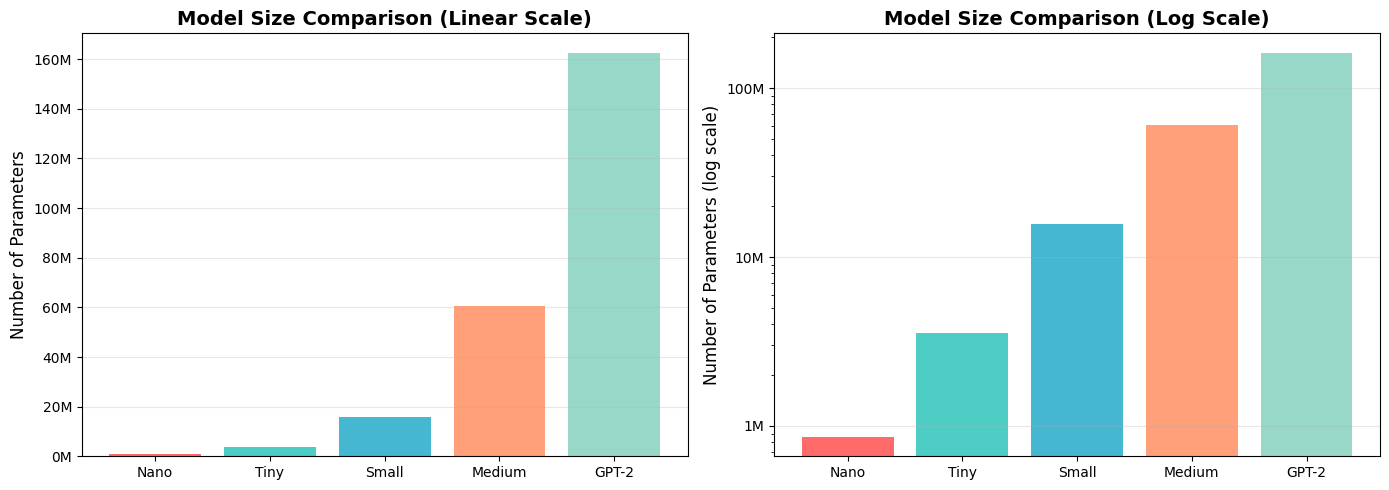


SCALING ANALYSIS:
----------------------------------------------------------------------------------------------------
Parameter growth ratios:
  Nano → Tiny: 4.1x
  Tiny → Small: 4.4x
  Small → Medium: 3.8x
  Medium → GPT-2: 2.7x



In [12]:
# Define different GPT model sizes
model_configs = {
    'Nano': GPTConfig(vocab_size=256, d_model=64, num_layers=2, num_heads=4),
    'Tiny': GPTConfig(vocab_size=512, d_model=128, num_layers=4, num_heads=8),
    'Small': GPTConfig(vocab_size=2048, d_model=256, num_layers=8, num_heads=8),
    'Medium': GPTConfig(vocab_size=10000, d_model=512, num_layers=12, num_heads=16),
    'GPT-2': GPTConfig(vocab_size=50257, d_model=768, num_layers=12, num_heads=12),
}

print("=" * 100)
print("MODEL SIZE COMPARISON")
print("=" * 100)
print(f"{'Model':<15} {'Vocab':<10} {'d_model':<10} {'Layers':<8} {'Heads':<8} {'Parameters':<15} {'Size (MB)':<12}")
print("-" * 100)

model_sizes = {}
for name, cfg in model_configs.items():
    model = GPT(cfg)
    params = sum(p.numel() for p in model.parameters())
    model_sizes[name] = params
    size_mb = params * 4 / (1024 ** 2)
    print(f"{name:<15} {cfg.vocab_size:<10} {cfg.d_model:<10} {cfg.num_layers:<8} {cfg.num_heads:<8} {params:<15,} {size_mb:<12.1f}")

print("=" * 100)

# Visualize parameter scaling
names = list(model_sizes.keys())
sizes = list(model_sizes.values())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
ax1.bar(names, sizes, color=colors)
ax1.set_ylabel('Number of Parameters', fontsize=12)
ax1.set_title('Model Size Comparison (Linear Scale)', fontsize=14, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6)}M'))
ax1.grid(axis='y', alpha=0.3)

# Log scale
ax2.bar(names, sizes, color=colors)
ax2.set_ylabel('Number of Parameters (log scale)', fontsize=12)
ax2.set_title('Model Size Comparison (Log Scale)', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6)}M'))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print scaling analysis
print("\nSCALING ANALYSIS:")
print("-" * 100)
print("Parameter growth ratios:")
prev_size = sizes[0]
for i in range(1, len(sizes)):
    ratio = sizes[i] / prev_size
    print(f"  {names[i-1]} → {names[i]}: {ratio:.1f}x")
    prev_size = sizes[i]

print("\n" + "=" * 100)

## Section 13: Challenges and Future Enhancements

### Implementation Challenges Encountered

1. **Memory Management**: Larger models require careful attention to GPU/CPU memory
2. **Numerical Stability**: Hidden initialization and epsilon values are critical for LayerNorm
3. **Causal Masking**: Creating proper attention masks for autoregressive generation
4. **Positional Embeddings**: Balancing learned vs. fixed positional representations

### Potential Enhancements

1. **KV-Cache for Inference**: Store computed keys and values to speed up generation
2. **Mixed Precision**: Use fp16 for faster computation and lower memory
3. **Gradient Checkpointing**: Trade memory for computation during training
4. **Different Attention Mechanisms**: Flash Attention, Grouped Query Attention, etc.
5. **Alternative Positional Encodings**: Rotary embeddings, relative position bias
6. **Efficient Implementations**: Fused kernels for layer norm, attention, etc.

### Next Steps (Assignment 4 & 5)

- **Assignment 4**: Train this model on actual text data and monitor loss convergence
- **Assignment 5**: Fine-tune on downstream tasks (classification, instruction following)
- **Hyperparameter Tuning**: Explore different learning rates, dropout rates, layer counts
- **Evaluation**: Generate quality samples and measure perplexity on test set

### References

- Vaswani et al. "Attention is All You Need" (2017)
- Radford et al. "Language Models are Unsupervised Multitask Learners" (GPT-2, 2019)
- Raschka "Build a Large Language Model From Scratch" (2024)

---

**Assignment 3 Complete!** You've successfully built a complete GPT model architecture from scratch, understanding each component's role in the transformer architecture. In future assignments, you'll train this model on real data and fine-tune it for specific tasks.